In [1]:
def collect_data(var, local_path, region, start_date, end_date):

    var_arr  = []

    cleaned_list = [item for item in local_path if item != []]


    
    for item,file in enumerate(cleaned_list):

        print(f'reading file: {file.split("/")[-1]}, {item+1}/{len(cleaned_list)}')
        sys.stdout.flush()
        
        with xr.open_dataset(file,decode_timedelta=False) as ds:

            time_range = ds['time'].sel(time=slice(start_date, end_date))

            data = ds[var].sel(time=time_range,\
                            yt_ocean=slice(region[0][0], region[0][1]), \
                            xt_ocean=slice(region[1][0], region[1][1])).load()
            
            data = data.mean(dim=["yt_ocean", "xt_ocean"]) 
            
    
            original_units = ds[var].attrs.get('units', '')
            
        if original_units:
            data.attrs['units'] = original_units
    
        var_arr.append(data)

    return  var_arr
    

In [2]:
client = Client()
client


NameError: name 'Client' is not defined

Starting ACCESS-OM2 SOTS analysis....
Processing mld variable...
Scattering path for mld...
reading file: ocean-2d-mld-1-monthly-mean-ym_2004_01.nc, 1/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2004_04.nc, 2/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2004_07.nc, 3/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2004_10.nc, 4/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2005_01.nc, 5/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2005_04.nc, 6/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2005_07.nc, 7/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2005_10.nc, 8/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2006_01.nc, 9/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2006_04.nc, 10/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2006_07.nc, 11/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2006_10.nc, 12/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2007_01.nc, 13/60
reading file: ocean-2d-mld-1-monthly-mean-ym_2007_04.nc, 14/60
reading file: ocean-2d-mld-1-monthl

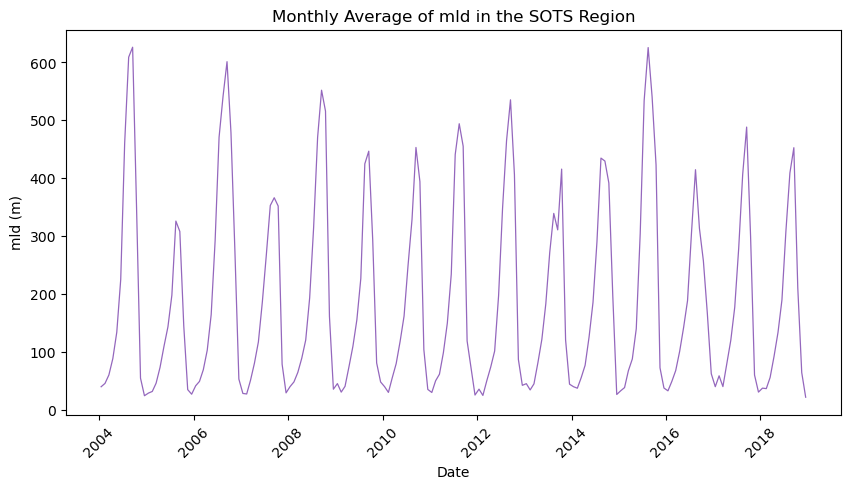

In [3]:
import os
import re
import sys
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client


catalog = intake.cat.access_nri


print('Starting ACCESS-OM2 SOTS analysis....')
sys.stdout.flush()

clim_start = 2004
clim_end = 2018

start_date = np.datetime64("2004-01-01")
end_date = np.datetime64("2018-12-31")

var = 'mld'

access_model='01deg_jra55v140_iaf'
deg = '01deg'


region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]


#----------------------------------------------------------------------------------------------
# This section collects all the variable paths
#----------------------------------------------------------------------------------------------
path_dict = {var: []}


catalog_filtered = catalog[access_model].search(
    variable=var,
    frequency='1mon',
    realm='ocean',
    
)

df = catalog_filtered.df[
    (catalog_filtered.df['start_date'] >= '2004-01-01') & 
    (catalog_filtered.df['start_date'] <= '2018-12-31') &
    (catalog_filtered.df['filename'].str.contains('mean'))
]

file_list = df['path'].tolist()

path_dict[var].extend(file_list)
path_dict[var].sort(key=lambda f: tuple(map(int, re.search(r'ym_(\d{4})_(\d{2})', f).groups())))


print(f'Processing {var} variable...')
sys.stdout.flush()


path_list = path_dict[var]

print(f'Scattering path for {var}...')
sys.stdout.flush()

    
local_var = collect_data(var, path_list, region, start_date, end_date)



local_var = xr.concat(local_var, dim='time')

anomaly = local_var

dates = local_var['time'].values

units = local_var.attrs.get("units", "")

anomaly.attrs['units'] = units


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates, anomaly, linestyle='-', color='tab:purple', linewidth=0.9)

ax.set_xlabel('Date')
ax.set_ylabel(f'{var} ({units})')
ax.set_title(f'Monthly Average of {var} in the SOTS Region')

plt.xticks(rotation=45)
plt.show()

        